In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))

from xso.parscans import run_xso_parscan, run_xso_stabilityscan

#from cariaco_ssm_setup import model, model_setup, model_setup_slim, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup,
)

from taniguchi_setup import model, model_setup

In [2]:
with model:
    output = model_setup.xsimlab.run()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [5]:
# --- Build steady-state seed from tail mean of the IVP run ---
AVG_WINDOW = 1000
FLOOR      = 1e-10   # strict positivity for fsolve

N_seed = float(output.Nutrient__value
               .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
P_seed = (output.Phytoplankton__biomass
          .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
Z_seed = (output.Microzooplankton__biomass
          .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

n_P_floored = int(np.sum(P_seed < FLOOR))
n_Z_floored = int(np.sum(Z_seed < FLOOR))
N_seed = max(N_seed, FLOOR)
P_seed = np.maximum(P_seed, FLOOR)
Z_seed = np.maximum(Z_seed, FLOOR)

print(f"Seed (last {AVG_WINDOW} d mean, floor = {FLOOR}):")
print(f"  N_seed   = {N_seed:.6g}")
print(f"  Σ P_seed = {P_seed.sum():.6g}   ({n_P_floored}/{len(P_seed)} entries at floor)")
print(f"  Σ Z_seed = {Z_seed.sum():.6g}   ({n_Z_floored}/{len(Z_seed)} entries at floor)")
print(f"  closure  = {N_seed + P_seed.sum() + Z_seed.sum():.6g}   (expect ~15.0)")

Seed (last 1000 d mean, floor = 1e-10):
  N_seed   = 0.00948808
  Σ P_seed = 13.1947   (0/501 entries at floor)
  Σ Z_seed = 1.79581   (248/501 entries at floor)
  closure  = 15   (expect ~15.0)


In [6]:
# --- Run stability solver seeded from the tail mean, with eigenvalue hook ---
from taniguchi_setup import model_setup_stability
from xso.parscans import StabilityAnalysisHook

hook = StabilityAnalysisHook()

with model:
    result_ss = (model_setup_stability
                 .xsimlab.update_vars(input_vars={
                     'Nutrient':         {'value_init':   N_seed},
                     'Phytoplankton':    {'biomass_init': P_seed},
                     'Microzooplankton': {'biomass_init': Z_seed},
                 })
                 .xsimlab.run(hooks=[hook]))

stability_data = hook.get_results()

# Steady state stored at time=-1 (XSO stability-solver convention)
N_star = float(result_ss.Nutrient__value.isel(time=-1).values)
P_star = result_ss.Phytoplankton__biomass.isel(time=-1).values
Z_star = result_ss.Microzooplankton__biomass.isel(time=-1).values

print(f"\nSteady state (fsolve):")
print(f"  N*       = {N_star:.6g}")
print(f"  Σ P*     = {P_star.sum():.6g}")
print(f"  Σ Z*     = {Z_star.sum():.6g}")
print(f"  closure  = {N_star + P_star.sum() + Z_star.sum():.6g}   (expect ~15.0)")

print(f"\nEigenvalue analysis:")
print(f"  stability              : {stability_data.get('stability')}")
print(f"  max eigenvalue (real)  : {stability_data.get('max_eigenvalue_real'):.4e}")
print(f"  n positive eigenvalues : {stability_data.get('n_positive_eigenvalues')}")
print(f"  n complex pairs        : {stability_data.get('n_complex_pairs')}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[INFO] Initial state dimension: 1003
[INFO] Initial state: [9.48807631e-03 4.53984639e-02 4.53410319e-02 ... 1.00000000e-10
 1.00000000e-10 1.00000000e-10]
[INFO] Steady state found with residual norm: 1.74e-14
  Steady state: [ 9.35948829e-03  4.24523213e-02  4.24686822e-02 ... -1.05537090e-45
  8.58510799e-47  1.00795140e-46]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 1003 eigenvalues
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 6.2200e-03

Steady state (fsolve):
  N*       = 0.00935949
  Σ P*     = 10.0664
  Σ Z*     = 1.69766
  closure  = 11.7734   (expect ~15.0)

Eigenvalue analysis:
  stability              : unstable
  max eigenvalue (real)  : 6.2200e-03
  n positive eigenvalues : 509
  n complex pairs        : 223


In [7]:
import numpy as np

# Taniguchi 2014 Table 1
mu_0, e_mu  = 1.36,  -0.16
k_s_0, e_ks = 0.33,  +0.48
g_0,   e_g  = 33.96, -0.66
k_z_0, e_kz = 17.92, -0.64
Gamma  = 0.31
Lambda_ = 0.0015
Delta_  = 0.025

# Closure at N_T=15 from the LaTeX baseline §6 / Table 1
N_T               = 15.0
N_star_analytical = 0.0099
s_max_analytical  = 175.0

# Evaluate on the model's own grid for direct comparability with result_ss
s       = result_ss.phyto.values
ratio   = 1.0182
delta_s = s * (ratio - 1)            # per-class linear width on the log grid

mu_arr  = mu_0  * s ** e_mu
k_s_arr = k_s_0 * s ** e_ks
g_arr   = g_0   * s ** e_g
k_z_arr = k_z_0 * s ** e_kz

# Analytical P*(s) — Taniguchi Eq. 6 (full form, not the unsaturated limit)
denom_P = Gamma * g_arr - Delta_
P_analytical = np.where(denom_P > 0, Delta_ * k_z_arr / denom_P, np.nan)

# Analytical Z*(s) — Taniguchi Eq. 9 with N* from the LaTeX closure solution
viability = mu_arr * N_star_analytical / (N_star_analytical + k_s_arr) - Lambda_
Z_analytical = np.where(viability > 0,
                        (P_analytical + k_z_arr) / g_arr * viability,
                        np.nan)

# Alive masks (s ≤ s_max AND positive)
alive_P = (s <= s_max_analytical) & np.isfinite(P_analytical) & (P_analytical > 0)
alive_Z = (s <= s_max_analytical) & np.isfinite(Z_analytical) & (Z_analytical > 0)

# Fit NBSS slopes on the analytical alive range
log_s_P   = np.log10(s[alive_P])
log_NBSSP = np.log10(P_analytical[alive_P] / delta_s[alive_P])
slope_P, icept_P = np.polyfit(log_s_P, log_NBSSP, 1)

log_s_Z   = np.log10(s[alive_Z])
log_NBSSZ = np.log10(Z_analytical[alive_Z] / delta_s[alive_Z])
slope_Z, icept_Z = np.polyfit(log_s_Z, log_NBSSZ, 1)

print(f"Analytical NBSS slopes at N_T = {N_T} µmol N L⁻¹:")
print(f"  Phyto:  {slope_P:+.3f}    (Taniguchi Table 2 range: -0.95 to -0.98)")
print(f"  Zoo  :  {slope_Z:+.3f}    (Taniguchi Table 2 range: -1.65 to -1.82)")
print()
print(f"Asymptotic-limit predictions (unsaturated grazing + linear uptake):")
print(f"  Phyto: e_kz − e_g − 1            = {e_kz - e_g - 1:+.3f}")
print(f"  Zoo  : e_kz − e_g + e_mu − e_ks − 1 = "
      f"{e_kz - e_g + e_mu - e_ks - 1:+.3f}")

Analytical NBSS slopes at N_T = 15.0 µmol N L⁻¹:
  Phyto:  -0.969    (Taniguchi Table 2 range: -0.95 to -0.98)
  Zoo  :  -1.929    (Taniguchi Table 2 range: -1.65 to -1.82)

Asymptotic-limit predictions (unsaturated grazing + linear uptake):
  Phyto: e_kz − e_g − 1            = -0.980
  Zoo  : e_kz − e_g + e_mu − e_ks − 1 = -1.620


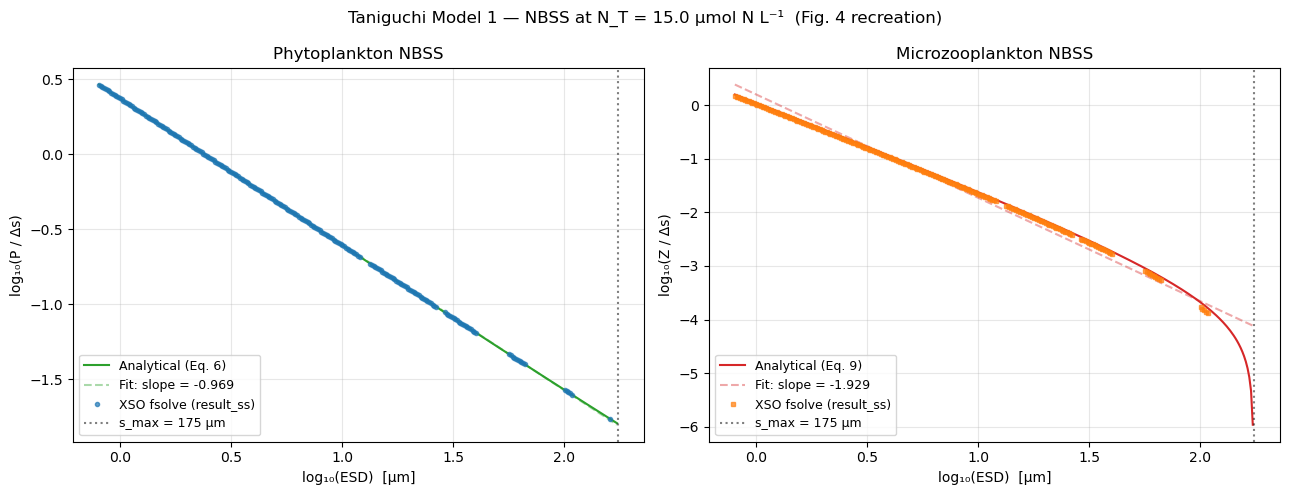

In [8]:
import matplotlib.pyplot as plt

P_xso = result_ss.Phytoplankton__biomass.isel(time=-1).values
Z_xso = result_ss.Microzooplankton__biomass.isel(time=-1).values

# Mask XSO outputs above floor noise and within the visible range
P_xso_mask = (P_xso > 1e-5) & (s <= 300)
Z_xso_mask = (Z_xso > 1e-5) & (s <= 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

# --- Phyto panel ---
ax = axes[0]
ax.plot(log_s_P, log_NBSSP, '-',  color='C2', lw=1.5,
        label='Analytical (Eq. 6)')
ax.plot(log_s_P, slope_P * log_s_P + icept_P, '--', color='C2', alpha=0.4,
        label=f'Fit: slope = {slope_P:+.3f}')
ax.plot(np.log10(s[P_xso_mask]),
        np.log10(P_xso[P_xso_mask] / delta_s[P_xso_mask]),
        'o', color='C0', ms=3, alpha=0.7,
        label='XSO fsolve (result_ss)')
ax.axvline(np.log10(s_max_analytical), color='k', ls=':', alpha=0.5,
           label=f's_max = {s_max_analytical:.0f} µm')
ax.set_xlabel('log₁₀(ESD)  [µm]')
ax.set_ylabel('log₁₀(P / Δs)')
ax.set_title('Phytoplankton NBSS')
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)

# --- Zoo panel ---
ax = axes[1]
ax.plot(log_s_Z, log_NBSSZ, '-',  color='C3', lw=1.5,
        label='Analytical (Eq. 9)')
ax.plot(log_s_Z, slope_Z * log_s_Z + icept_Z, '--', color='C3', alpha=0.4,
        label=f'Fit: slope = {slope_Z:+.3f}')
ax.plot(np.log10(s[Z_xso_mask]),
        np.log10(Z_xso[Z_xso_mask] / delta_s[Z_xso_mask]),
        's', color='C1', ms=3, alpha=0.7,
        label='XSO fsolve (result_ss)')
ax.axvline(np.log10(s_max_analytical), color='k', ls=':', alpha=0.5,
           label=f's_max = {s_max_analytical:.0f} µm')
ax.set_xlabel('log₁₀(ESD)  [µm]')
ax.set_ylabel('log₁₀(Z / Δs)')
ax.set_title('Microzooplankton NBSS')
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)

fig.suptitle(f'Taniguchi Model 1 — NBSS at N_T = {N_T} µmol N L⁻¹  '
             f'(Fig. 4 recreation)', fontsize=12)
plt.tight_layout()

In [9]:
bin_centres = np.array([1.0, 6.3, 63.0])

print(f"Per-class P*(s) at Cariaco bin geomeans  (N_T = {N_T} µmol N L⁻¹):\n")
print(f"{'ESD':>6} | {'Eq.6 full':>10} | {'Eq.8 limit':>10} | "
      f"{'XSO':>10} | {'XSO−Eq.6':>9}")
print("-" * 56)
for esd in bin_centres:
    k_z_b = k_z_0 * esd ** e_kz
    g_b   = g_0   * esd ** e_g
    P_eq6 = Delta_ * k_z_b / (Gamma * g_b - Delta_)
    P_eq8 = 0.0425 * esd ** 0.02
    i     = int(np.argmin(np.abs(s - esd)))
    P_xso_at = float(P_xso[i])
    rel_diff = (P_xso_at - P_eq6) / P_eq6 * 100
    print(f"{esd:>6.1f} | {P_eq6:>10.4f} | {P_eq8:>10.4f} | "
          f"{P_xso_at:>10.4f} | {rel_diff:>+8.1f}%")

Per-class P*(s) at Cariaco bin geomeans  (N_T = 15.0 µmol N L⁻¹):

   ESD |  Eq.6 full | Eq.8 limit |        XSO |  XSO−Eq.6
--------------------------------------------------------
   1.0 |     0.0427 |     0.0425 |     0.0426 |     -0.0%
   6.3 |     0.0445 |     0.0441 |     0.0445 |     -0.0%
  63.0 |     0.0480 |     0.0462 |     0.0480 |     -0.0%


In [10]:
# --- Refine zoo NBSS fit by restricting to the asymptotic regime ---
growth_term = mu_arr * N_star_analytical / (N_star_analytical + k_s_arr)
asymptotic_regime = (growth_term > 2.0 * Lambda_) & alive_Z

log_s_Z_a   = np.log10(s[asymptotic_regime])
log_NBSSZ_a = np.log10(Z_analytical[asymptotic_regime] / delta_s[asymptotic_regime])
slope_Z_a, icept_Z_a = np.polyfit(log_s_Z_a, log_NBSSZ_a, 1)

s_a_max = s[asymptotic_regime].max()
print(f"Zoo NBSS slope, restricted to growth > 2·Λ  (s ≤ {s_a_max:.1f} µm):")
print(f"  {slope_Z_a:+.3f}    (Taniguchi Table 2 range: -1.65 to -1.82)")
print(f"  asymptotic limit: {e_kz - e_g + e_mu - e_ks - 1:+.3f}")

# Per-class Z*(s) at Cariaco centres (Eq. 9 form, mirrors Cell E)
print()
print(f"Per-class Z*(s) at Cariaco bin geomeans  (N_T = {N_T} µmol N L⁻¹):\n")
print(f"{'ESD':>6} | {'Eq.9 full':>10} | {'XSO':>10} | {'XSO−Eq.9':>9}")
print("-" * 45)
for esd in bin_centres:
    k_z_b = k_z_0  * esd ** e_kz
    g_b   = g_0    * esd ** e_g
    k_s_b = k_s_0  * esd ** e_ks
    mu_b  = mu_0   * esd ** e_mu
    P_eq6 = Delta_ * k_z_b / (Gamma * g_b - Delta_)
    viability_b = mu_b * N_star_analytical / (N_star_analytical + k_s_b) - Lambda_
    Z_eq9 = (P_eq6 + k_z_b) / g_b * viability_b
    i     = int(np.argmin(np.abs(s - esd)))
    Z_xso_at = float(Z_xso[i])
    rel_diff = (Z_xso_at - Z_eq9) / Z_eq9 * 100
    print(f"{esd:>6.1f} | {Z_eq9:>10.4f} | {Z_xso_at:>10.4f} | {rel_diff:>+8.1f}%")

Zoo NBSS slope, restricted to growth > 2·Λ  (s ≤ 58.5 µm):
  -1.732    (Taniguchi Table 2 range: -1.65 to -1.82)
  asymptotic limit: -1.620

Per-class Z*(s) at Cariaco bin geomeans  (N_T = 15.0 µmol N L⁻¹):

   ESD |  Eq.9 full |        XSO |  XSO−Eq.9
---------------------------------------------
   1.0 |     0.0202 |     0.0191 |     -5.1%
   6.3 |     0.0060 |     0.0057 |     -5.6%
  63.0 |     0.0008 |     0.0007 |    -11.2%


In [11]:
N_star_xso = float(result_ss.Nutrient__value.isel(time=-1).values)

print(f"Z*(s) using the XSO-converged N* = {N_star_xso:.5g}:\n")
print(f"{'ESD':>6} | {'Eq.9 (N_xso)':>13} | {'XSO':>10} | {'diff':>9}")
print("-" * 46)
for esd in bin_centres:
    k_z_b = k_z_0  * esd ** e_kz
    g_b   = g_0    * esd ** e_g
    k_s_b = k_s_0  * esd ** e_ks
    mu_b  = mu_0   * esd ** e_mu
    P_eq6 = Delta_ * k_z_b / (Gamma * g_b - Delta_)
    viab  = mu_b * N_star_xso / (N_star_xso + k_s_b) - Lambda_
    Z_eq9 = (P_eq6 + k_z_b) / g_b * viab
    i     = int(np.argmin(np.abs(s - esd)))
    Z_xso_at = float(Z_xso[i])
    rel = (Z_xso_at - Z_eq9) / Z_eq9 * 100
    print(f"{esd:>6.1f} | {Z_eq9:>13.4f} | {Z_xso_at:>10.4f} | {rel:>+8.1f}%")

Z*(s) using the XSO-converged N* = 0.0093595:

   ESD |  Eq.9 (N_xso) |        XSO |      diff
----------------------------------------------
   1.0 |        0.0190 |     0.0191 |     +0.4%
   6.3 |        0.0057 |     0.0057 |     +0.5%
  63.0 |        0.0007 |     0.0007 |     +0.2%


In [12]:
from scipy.optimize import brentq

def closure_residual(s_max, N_T):
    """
    Taniguchi closure Eq. 14 (LaTeX baseline). Solves implicitly for the
    spectrum extent s_max at given total nitrogen N_T, using the
    unsaturated-grazing and linear-uptake limits:

        N* = s_max^0.64 / 2747
        N_T = N*·[1 + 195·(1.149 − s_max^-0.62)]
              + 115.8·(s_max^0.02 − 0.9956)
    """
    N = s_max**0.64 / 2747.0
    return (N * (1.0 + 195.0 * (1.149 - s_max**(-0.62)))
            + 115.8 * (s_max**0.02 - 0.9956)
            - N_T)

N_T_values = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
print(f"Analytical s_max(N_T) from LaTeX Eq. 14:\n")
print(f"{'N_T':>4} | {'s_max':>10} | {'N*':>9} | {'paper text':>14}")
print("-" * 49)
for NT in N_T_values:
    s_max = brentq(closure_residual, 0.8, 6500.0, args=(NT,))
    N_star = s_max**0.64 / 2747.0
    paper = {10: '39 µm', 30: '~1915 µm'}.get(int(NT), '')
    print(f"{NT:>4.0f} | {s_max:>8.1f} µm | {N_star:>9.5f} | {paper:>14}")

Analytical s_max(N_T) from LaTeX Eq. 14:

 N_T |      s_max |        N* |     paper text
-------------------------------------------------
   5 |      6.2 µm |   0.00117 |               
  10 |     37.8 µm |   0.00372 |          39 µm
  15 |    163.7 µm |   0.00951 |               
  20 |    488.3 µm |   0.01914 |               
  25 |   1087.9 µm |   0.03196 |               
  30 |   1987.8 µm |   0.04700 |       ~1915 µm


In [13]:
# Two fresh IVP runs — budget several minutes each at 5000 d × 501 classes.

N_T_xso_check = [10.0, 30.0]
xso_smax_results = {}

n_classes = len(s)
phyto_init_default = np.full(n_classes, 1e-4)
zoo_init_default   = np.full(n_classes, 1e-4)

for NT in N_T_xso_check:
    N_init_new = NT - phyto_init_default.sum() - zoo_init_default.sum()
    print(f"Running N_T = {NT}  (N_init = {N_init_new:.3f}) ...")
    with model:
        out_nt = (model_setup
                  .xsimlab.update_vars(input_vars={
                      'Nutrient': {'value_init': N_init_new},
                  })
                  .xsimlab.run())

    # Tail-mean over the last 1000 days as the steady-state estimate
    P_tail = (out_nt.Phytoplankton__biomass
              .isel(time=slice(-1000, None)).mean('time').values)

    # Numerical s_max: largest s where the tail-mean biomass exceeds 1% of peak
    threshold = 0.01 * P_tail.max()
    alive     = P_tail > threshold
    s_max_num = float(s[alive].max()) if alive.any() else float('nan')

    # Closure diagnostic at the tail-mean
    N_tail = float(out_nt.Nutrient__value.isel(time=slice(-1000, None)).mean('time').values)
    Z_tail = (out_nt.Microzooplankton__biomass
              .isel(time=slice(-1000, None)).mean('time').values)
    closure_tail = N_tail + P_tail.sum() + Z_tail.sum()

    xso_smax_results[NT] = {
        's_max_num': s_max_num,
        'closure':   closure_tail,
        'N_tail':    N_tail,
    }
    print(f"  s_max (numerical, 1% of peak) = {s_max_num:.1f} µm")
    print(f"  closure (tail-mean) = {closure_tail:.3f}  (expect {NT})")
    print(f"  N*  (tail-mean)     = {N_tail:.5g}")

# Comparison table
print(f"\n{'N_T':>4} | {'XSO IVP s_max':>14} | {'Analytical':>11} | {'Paper text':>12}")
print("-" * 55)
for NT in N_T_xso_check:
    s_xso = xso_smax_results[NT]['s_max_num']
    s_ana = brentq(closure_residual, 0.8, 6500.0, args=(NT,))
    paper = {10.0: '39 µm', 30.0: '~1915 µm'}[NT]
    print(f"{NT:>4.0f} | {s_xso:>12.1f} µm | {s_ana:>9.1f} µm | {paper:>12}")

Running N_T = 10.0  (N_init = 9.900) ...
  s_max (numerical, 1% of peak) = 65.2 µm
  closure (tail-mean) = 10.000  (expect 10.0)
  N*  (tail-mean)     = 0.0033294
Running N_T = 30.0  (N_init = 29.900) ...
  s_max (numerical, 1% of peak) = 1504.3 µm
  closure (tail-mean) = 30.000  (expect 30.0)
  N*  (tail-mean)     = 0.03877

 N_T |  XSO IVP s_max |  Analytical |   Paper text
-------------------------------------------------------
  10 |         65.2 µm |      37.8 µm |        39 µm
  30 |       1504.3 µm |    1987.8 µm |     ~1915 µm


In [14]:
# Re-run IVP at N_T = 10 and 30 with full tail-mean arrays stored

N_T_xso_check = [10.0, 30.0]
xso_smax_results = {}

n_classes = len(s)
phyto_init_default = np.full(n_classes, 1e-4)
zoo_init_default   = np.full(n_classes, 1e-4)

for NT in N_T_xso_check:
    N_init_new = NT - phyto_init_default.sum() - zoo_init_default.sum()
    print(f"Running N_T = {NT}  (N_init = {N_init_new:.3f}) ...")
    with model:
        out_nt = (model_setup
                  .xsimlab.update_vars(input_vars={
                      'Nutrient': {'value_init': N_init_new},
                  })
                  .xsimlab.run())

    P_tail = (out_nt.Phytoplankton__biomass
              .isel(time=slice(-1000, None)).mean('time').values)
    Z_tail = (out_nt.Microzooplankton__biomass
              .isel(time=slice(-1000, None)).mean('time').values)
    N_tail = float(out_nt.Nutrient__value
                   .isel(time=slice(-1000, None)).mean('time').values)

    threshold = 0.01 * P_tail.max()
    alive     = P_tail > threshold
    s_max_num = float(s[alive].max()) if alive.any() else float('nan')
    closure_tail = N_tail + P_tail.sum() + Z_tail.sum()

    xso_smax_results[NT] = {
        's_max_num': s_max_num,
        'closure':   closure_tail,
        'N_tail':    N_tail,
        'P_tail':    P_tail,
        'Z_tail':    Z_tail,
    }
    print(f"  s_max (1% of peak) = {s_max_num:.1f} µm,  "
          f"closure = {closure_tail:.3f},  N* = {N_tail:.5g}")

Running N_T = 10.0  (N_init = 9.900) ...
  s_max (1% of peak) = 65.2 µm,  closure = 10.000,  N* = 0.0033294
Running N_T = 30.0  (N_init = 29.900) ...
  s_max (1% of peak) = 1504.3 µm,  closure = 30.000,  N* = 0.03877


In [15]:
# Per-class P*(s) verification across the three N_T values
# Eq. 6 (P*) is N-independent — analytical column is the same at every N_T

print(f"P*(s) verification across N_T  (Eq. 6 is N-independent):\n")
print(f"{'ESD':>5} | {'Eq.6':>8} | "
      f"{'N_T=10':>9} | {'diff':>7} | "
      f"{'N_T=15':>9} | {'diff':>7} | "
      f"{'N_T=30':>9} | {'diff':>7}")
print("-" * 74)

P15_arr = result_ss.Phytoplankton__biomass.isel(time=-1).values

for esd in bin_centres:
    k_z_b = k_z_0 * esd ** e_kz
    g_b   = g_0   * esd ** e_g
    P_eq6 = Delta_ * k_z_b / (Gamma * g_b - Delta_)
    i     = int(np.argmin(np.abs(s - esd)))
    P10 = float(xso_smax_results[10.0]['P_tail'][i])
    P15 = float(P15_arr[i])
    P30 = float(xso_smax_results[30.0]['P_tail'][i])
    d10 = (P10 - P_eq6) / P_eq6 * 100
    d15 = (P15 - P_eq6) / P_eq6 * 100
    d30 = (P30 - P_eq6) / P_eq6 * 100
    print(f"{esd:>5.1f} | {P_eq6:>8.4f} | "
          f"{P10:>9.4f} | {d10:>+6.1f}% | "
          f"{P15:>9.4f} | {d15:>+6.1f}% | "
          f"{P30:>9.4f} | {d30:>+6.1f}%")

P*(s) verification across N_T  (Eq. 6 is N-independent):

  ESD |     Eq.6 |    N_T=10 |    diff |    N_T=15 |    diff |    N_T=30 |    diff
--------------------------------------------------------------------------
  1.0 |   0.0427 |    0.0457 |   +7.3% |    0.0426 |   -0.0% |    0.0397 |   -6.9%
  6.3 |   0.0445 |    0.0487 |   +9.4% |    0.0445 |   -0.0% |    0.0385 |  -13.4%
 63.0 |   0.0480 |    0.0010 |  -97.8% |    0.0480 |   -0.0% |    0.0070 |  -85.3%
